In [ ]:
"""
%pip install numpy
%pip install pandas
%pip install torch
%pip install matplotlib
%pip install statsmodels
%pip install scikit-learn
%pip install scipy
%pip install PyWavelets
%pip install ruptures
"""

In [ ]:
from pathlib import Path

def find_chapter_dir(start=None):
    """Locate work/07-change_stats from the notebook cwd or repository root."""
    start = (start or Path.cwd()).resolve()
    markers = [
        Path("data") / "berkeley_earth.txt",
        Path("work") / "07-change_stats" / "data" / "berkeley_earth.txt",
        Path("Seminar_ClimateNStatistics26") / "work" / "07-change_stats" / "data" / "berkeley_earth.txt",
    ]

    for path in [start, *start.parents]:
        for marker in markers:
            candidate = path / marker
            if candidate.is_file():
                # return the chapter directory that contains data/
                return candidate.parents[1]

    raise FileNotFoundError(
        "Could not find work/07-change_stats/data/berkeley_earth.txt. "
        "Open the notebook from the cloned repository "
        "(e.g. work/07-change_stats/code/) or set the working directory to the repo."
    )

CHAPTER_DIR = find_chapter_dir()
DATA_DIR = CHAPTER_DIR / "data"
FIGURE_DIR = CHAPTER_DIR / "figures"
RESULT_DIR = CHAPTER_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("CHAPTER_DIR:", CHAPTER_DIR)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pywt
import ruptures as rpt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler

from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Notes

Berkeley Earth land monthly anomalies (source): https://berkeleyearth.org/data/

Local copy used in this notebook:

`work/07-change_stats/data/berkeley_earth.txt`

Monthly series, unsupervised setting (no change-point labels).

In [ ]:
cols = [
    "Year", "Month",
    "Monthly", "Monthly_Unc",
    "Annual", "Annual_Unc",
    "FiveYear", "FiveYear_Unc",
    "TenYear", "TenYear_Unc",
    "TwentyYear", "TwentyYear_Unc",
]

df = pd.read_csv(
    DATA_DIR / "berkeley_earth.txt",
    comment="%",
    sep=r"\s+",
    header=None,
    names=cols,
)

# Monthly climatology means (1951–1980)
monthly_avg = {
    1: 2.56, 2: 3.19, 3: 5.29, 4: 8.29, 5: 11.28, 6: 13.43,
    7: 14.31, 8: 13.84, 9: 12.05, 10: 9.20, 11: 6.05, 12: 3.60,
}

df["Monthly_Average_1951_1980"] = df["Month"].map(monthly_avg)
df["Monthly_Absolute"] = df["Monthly"] + df["Monthly_Average_1951_1980"]
df["Annual_Absolute"] = df["Annual"] + 8.59

df.to_csv(DATA_DIR / "BerkeleyEarth_land_absolute.csv", index=False)

df = df.drop(columns=[
    "Annual", "Annual_Unc",
    "FiveYear", "FiveYear_Unc",
    "TenYear", "TenYear_Unc",
    "TwentyYear", "TwentyYear_Unc",
    "Monthly_Average_1951_1980",
    "Annual_Absolute",
])

In [ ]:
# Build monthly datetime index and keep anomaly column
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df = df.drop(columns=["Year", "Month", "Monthly_Unc", "Monthly_Absolute"])
df = df.rename(columns={"Monthly": "monthly_anomalies"})

In [ ]:
# Check that months are equidistant (required by the CPD setup)
full_range = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="MS")
missing_dates = full_range.difference(df["date"])

print(missing_dates)
print("Number of dates missing:", len(missing_dates))

In [ ]:
df = df.set_index("date")
y = df["monthly_anomalies"]

print("NaNs beforehand:", y.isna().sum())

# Fill gaps in the monthly series
y = y.interpolate(method="time")
y = y.ffill().bfill()

print("NaNs afterwards:", y.isna().sum())

v = "Monthly Land Temperature Anomalies"

# Phase 1 – Exploratory Data Analysis

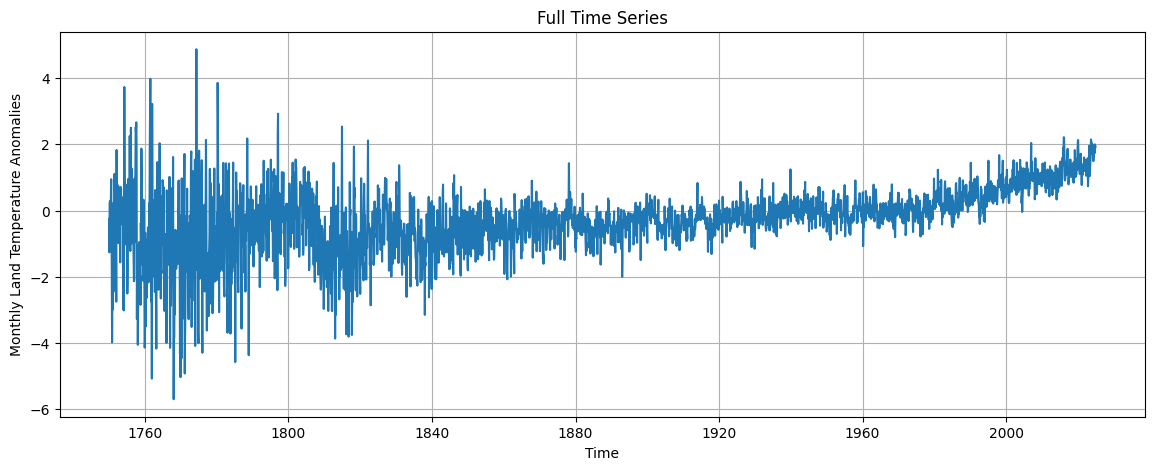

In [43]:
plt.figure(figsize = (14, 5))
plt.plot(y)
plt.title('Full Time Series')
plt.xlabel('Time')
plt.ylabel(v)
plt.grid(True)
plt.show()

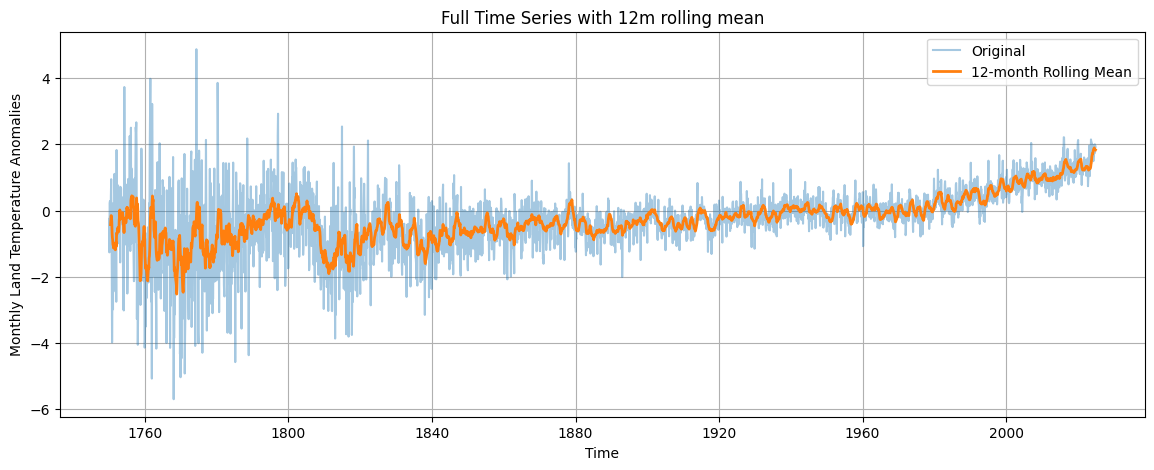

In [44]:
rolling_mean = y.rolling(window=12, min_periods=6).mean()

plt.figure(figsize=(14, 5))
plt.plot(y, alpha=0.4, label="Original")
plt.plot(rolling_mean.index, rolling_mean.values, linewidth=2, label="12-month Rolling Mean")
plt.title("Full Time Series with 12m rolling mean")
plt.xlabel("Time")
plt.ylabel(v)
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURE_DIR / "full_time_series.pdf",
    bbox_inches="tight"
)

plt.show()

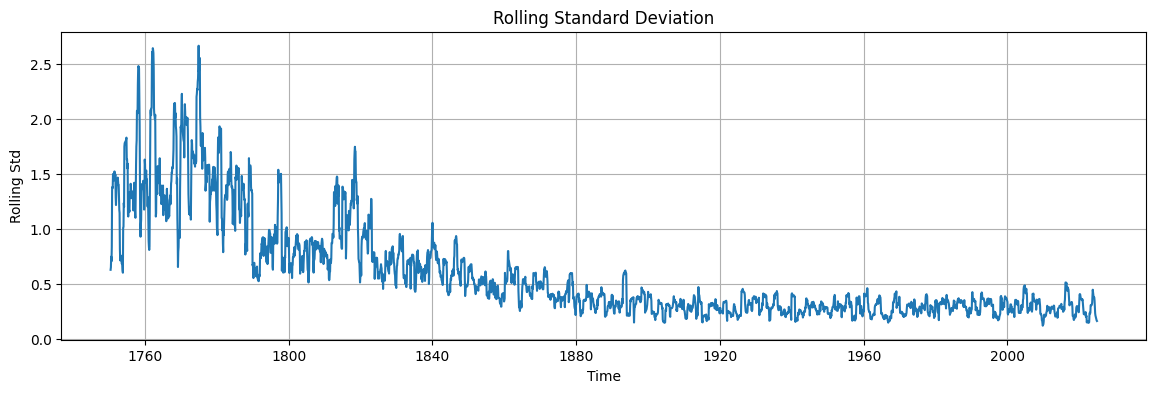

In [45]:
rolling_std = y.rolling(window=12, min_periods=6).std()

plt.figure(figsize=(14, 4))
plt.plot(rolling_std.index, rolling_std.values)
plt.title("Rolling Standard Deviation")
plt.xlabel("Time")
plt.ylabel("Rolling Std")
plt.grid(True)

plt.savefig(
    FIGURE_DIR / "rolling_std.pdf",
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x500 with 0 Axes>

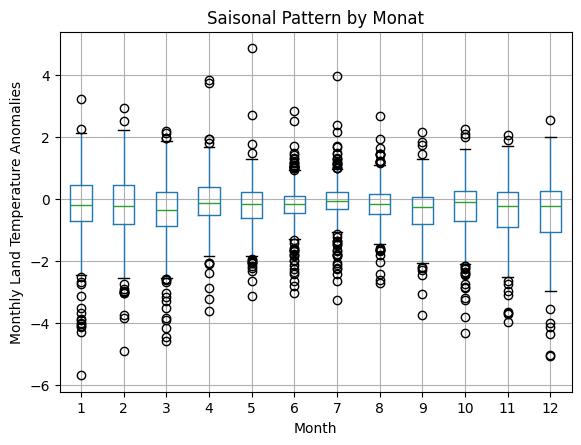

In [46]:
df_plot = y.to_frame("value")
df_plot['month'] = df_plot.index.month

plt.figure(figsize = (10, 5))
df_plot.boxplot(column = "value", by = "month")
plt.title("Saisonal Pattern by Monat")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel(v)
plt.grid(True)

plt.savefig(
    FIGURE_DIR / "seasonal_pattern.pdf",
    bbox_inches="tight"
)

plt.show()

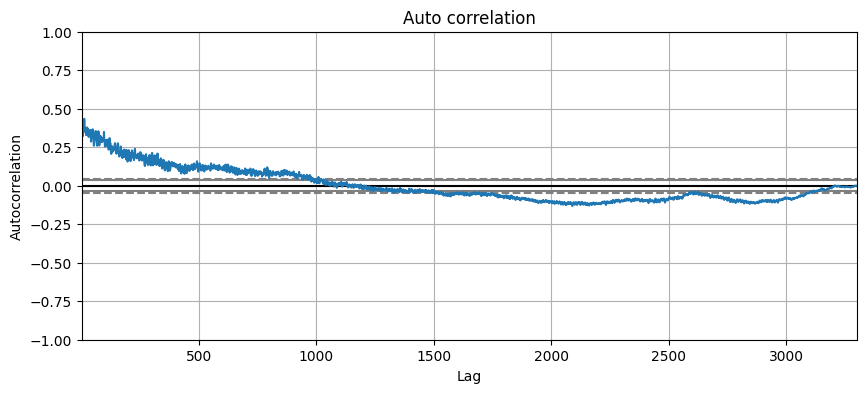

In [47]:
plt.figure(figsize=(10, 4))
autocorrelation_plot(y.dropna())
plt.title("Auto correlation")
plt.grid(True)
plt.show()

<Figure size 1200x500 with 0 Axes>

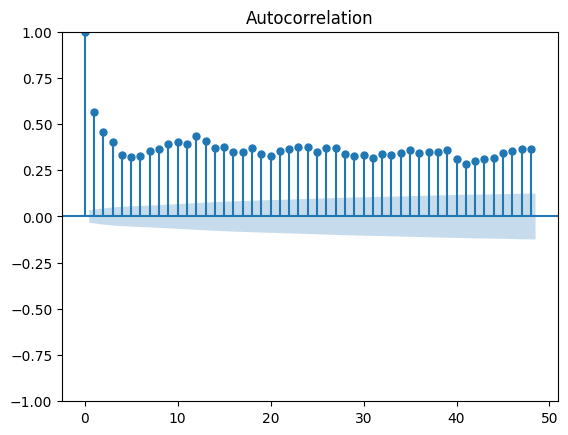

In [48]:
plt.figure(figsize=(12,5))

plot_acf(
    y.dropna(),
    lags=48,
    alpha=0.05
)


plt.savefig(
    FIGURE_DIR / "autocorrelation.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
plot_pacf(y.dropna(), lags=48, method="ywm")

plt.savefig(
    FIGURE_DIR / "partial_autocorrelation.pdf",
    bbox_inches="tight",
)
plt.show()

In [ ]:
# Rolling statistical features (EDA): mean, std, local slope, lag-1 ACF

VALUE_COL = "monthly_anomalies"
ROLLING_WINDOW_MONTHS = 120  # 10-year rolling window
MIN_PERIODS = 60             # at least 5 years of data
ACF_LAG = 1
OUTPUT_PATH = FIGURE_DIR / "rolling_statistical_features.png"

if VALUE_COL not in df.columns:
    raise KeyError(
        f"Column '{VALUE_COL}' was not found. "
        f"Available columns: {list(df.columns)}"
    )

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError("df must have a pandas DatetimeIndex.")

plot_df = df[[VALUE_COL]].copy()
plot_df[VALUE_COL] = pd.to_numeric(plot_df[VALUE_COL], errors="coerce")
plot_df = plot_df.sort_index().dropna(subset=[VALUE_COL])

if plot_df.index.has_duplicates:
    plot_df = (
        plot_df.groupby(level=0)[VALUE_COL].mean().to_frame()
    )

if len(plot_df) < MIN_PERIODS:
    raise ValueError(
        f"Not enough observations. At least {MIN_PERIODS} valid values "
        f"are required, but only {len(plot_df)} are available."
    )


def calculate_local_slope(values):
    """Linear trend slope within one rolling window (anomaly units per month)."""
    y_loc = np.asarray(values, dtype=float)
    y_loc = y_loc[np.isfinite(y_loc)]
    if len(y_loc) < 2:
        return np.nan
    x = np.arange(len(y_loc), dtype=float)
    return np.polyfit(x, y_loc, deg=1)[0]


def calculate_local_autocorrelation(values, lag=1):
    """Autocorrelation at the selected lag within one rolling window."""
    y_loc = pd.Series(values, dtype=float).dropna()
    if len(y_loc) <= lag or np.isclose(y_loc.std(), 0):
        return np.nan
    return y_loc.autocorr(lag=lag)


series = plot_df[VALUE_COL]
rolling_object = series.rolling(
    window=ROLLING_WINDOW_MONTHS,
    min_periods=MIN_PERIODS,
    center=True,
)

plot_df["rolling_mean"] = rolling_object.mean()
plot_df["rolling_std"] = rolling_object.std()
plot_df["rolling_slope_month"] = rolling_object.apply(
    calculate_local_slope, raw=True
)
plot_df["rolling_slope_decade"] = plot_df["rolling_slope_month"] * 12 * 10
plot_df["rolling_acf"] = rolling_object.apply(
    lambda values: calculate_local_autocorrelation(values, lag=ACF_LAG),
    raw=False,
)

Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 9.5), sharex=True)

axes[0].plot(plot_df.index, plot_df["rolling_mean"], linewidth=1.6)
axes[0].set_title("Rolling Mean")
axes[0].set_ylabel("Mean anomaly")
axes[0].grid(alpha=0.5)

axes[1].plot(plot_df.index, plot_df["rolling_std"], linewidth=1.6)
axes[1].set_title("Rolling Standard Deviation")
axes[1].set_ylabel("Standard deviation")
axes[1].grid(alpha=0.5)

axes[2].plot(plot_df.index, plot_df["rolling_slope_decade"], linewidth=1.6)
axes[2].axhline(y=0, linewidth=1, linestyle="--")
axes[2].set_title("Rolling Trend / Slope")
axes[2].set_ylabel("Anomaly change\nper decade")
axes[2].grid(alpha=0.5)

axes[3].plot(
    plot_df.index,
    plot_df["rolling_acf"],
    linewidth=1.6,
    label=f"ACF lag {ACF_LAG}",
)
axes[3].axhline(y=0, linewidth=1, linestyle="--")
axes[3].set_title("Rolling Autocorrelation")
axes[3].set_ylabel(f"ACF lag {ACF_LAG}")
axes[3].set_xlabel("Date")
axes[3].set_ylim(-1, 1)
axes[3].legend(loc="best")
axes[3].grid(alpha=0.5)

fig.suptitle(
    f"Local Statistical Features Using a "
    f"{ROLLING_WINDOW_MONTHS // 12}-Year Rolling Window",
    fontsize=15,
    y=0.995,
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

# Deep Learning Pipeline

### Wavelet–CNN with contrastive training

In [ ]:
# Wavelet-CNN contrastive CPD
# Requires: y = monthly anomaly series with DatetimeIndex

# Settings
WINDOW = 144
STEP = 3
N_SCALES = 48
BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3
LATENT_DIM = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
np.random.seed(42)


def clean_series(series):
    return series.dropna().astype(float)


def zscore_values(values):
    scaler = StandardScaler()
    values_scaled = scaler.fit_transform(values.reshape(-1, 1)).flatten()
    return values_scaled, scaler


def normalize_score(s):
    s = np.asarray(s)
    return (s - np.min(s)) / (np.max(s) - np.min(s) + 1e-8)


def wavelet_scalogram(x, n_scales=N_SCALES):
    """Morlet CWT magnitudes -> log1p -> per-window z-score."""
    scales = np.arange(1, n_scales + 1)
    coeffs, _ = pywt.cwt(x, scales, "morl")
    power = np.log1p(np.abs(coeffs))
    power = (power - power.mean()) / (power.std() + 1e-8)
    return power.astype(np.float32)


def make_windows(y_scaled, dates):
    raw_windows, scalograms, centers = [], [], []
    values = np.asarray(y_scaled)

    for start in range(0, len(values) - WINDOW + 1, STEP):
        end = start + WINDOW
        x = values[start:end]
        raw_windows.append(x.astype(np.float32))
        scalograms.append(wavelet_scalogram(x))
        centers.append(dates[start + WINDOW // 2])

    return (
        np.array(raw_windows),
        np.array(scalograms),
        pd.to_datetime(centers),
    )


def autocorr(x, lag):
    if lag >= len(x):
        return 0.0
    x1, x2 = x[:-lag], x[lag:]
    if np.std(x1) < 1e-8 or np.std(x2) < 1e-8:
        return 0.0
    return np.corrcoef(x1, x2)[0, 1]


def rolling_features_for_interpretation(raw_windows, centers):
    rows = []
    for x in raw_windows:
        t = np.arange(len(x))
        rows.append({
            "mean": np.mean(x),
            "std": np.std(x),
            "slope": np.polyfit(t, x, 1)[0],
            "acf_lag_1": autocorr(x, 1),
        })
    return pd.DataFrame(rows, index=centers)


# Prepare windows and scalograms
y_clean = clean_series(y)
dates = y_clean.index
y_scaled, _ = zscore_values(y_clean.values)

raw_windows, scalograms, centers = make_windows(y_scaled, dates)
features_df = rolling_features_for_interpretation(raw_windows, centers)

print("Number of windows:", len(raw_windows))
print("Raw windows:", raw_windows.shape)
print("Scalograms:", scalograms.shape)
print("Device:", DEVICE)


class AdjacentScalogramDataset(Dataset):
    """Positive pairs = temporally adjacent scalograms."""

    def __init__(self, scalograms):
        self.scalograms = torch.tensor(
            scalograms, dtype=torch.float32
        ).unsqueeze(1)

    def __len__(self):
        return len(self.scalograms) - 1

    def __getitem__(self, idx):
        return self.scalograms[idx], self.scalograms[idx + 1]


dataset = AdjacentScalogramDataset(scalograms)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


class WaveletCNNEncoder(nn.Module):
    """2D CNN: scalogram -> unit-norm embedding."""

    def __init__(self, window_len, n_scales, latent_dim=32):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        cnn_dim = 64 * (n_scales // 8) * (window_len // 8)
        self.projector = nn.Sequential(
            nn.Linear(cnn_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, wave):
        z = self.projector(self.cnn(wave))
        return F.normalize(z, dim=1)


encoder = WaveletCNNEncoder(
    window_len=WINDOW,
    n_scales=N_SCALES,
    latent_dim=LATENT_DIM,
).to(DEVICE)

optimizer = torch.optim.Adam(encoder.parameters(), lr=LR)


def contrastive_temporal_loss(z1, z2, temperature=0.2):
    """Symmetric InfoNCE over adjacent-window pairs in the batch."""
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_12 = F.cross_entropy(logits, labels)
    loss_21 = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_12 + loss_21)


# Train encoder
loss_history = []

for epoch in range(EPOCHS):
    encoder.train()
    epoch_loss = 0.0

    for wave1, wave2 in loader:
        wave1 = wave1.to(DEVICE)
        wave2 = wave2.to(DEVICE)

        optimizer.zero_grad()
        z1 = encoder(wave1)
        z2 = encoder(wave2)
        loss = contrastive_temporal_loss(z1, z2)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * wave1.size(0)

    epoch_loss /= len(dataset)
    loss_history.append(epoch_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:03d}/{EPOCHS} | Loss: {epoch_loss:.5f}")


# Embeddings and transition score
encoder.eval()
all_wave = torch.tensor(scalograms, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    embeddings = encoder(all_wave).cpu().numpy()

cosine_similarity = np.sum(embeddings[:-1] * embeddings[1:], axis=1)
change_score_raw = normalize_score(1 - cosine_similarity)
score_dates = centers[1:]

### Postprocessing

In [ ]:
# Postprocessing hyperparameters
POST_SMOOTH_SIGMA = 4
POST_MIN_HEIGHT = 0.6
POST_MIN_DISTANCE_MONTHS = 120

post_min_distance_windows = max(1, POST_MIN_DISTANCE_MONTHS // STEP)

# Smooth score, then select peaks by height and minimum distance
change_score_smooth = normalize_score(
    gaussian_filter1d(change_score_raw, sigma=POST_SMOOTH_SIGMA)
)

smooth_peaks_all, _ = find_peaks(change_score_smooth)
height_peaks, _ = find_peaks(change_score_smooth, height=POST_MIN_HEIGHT)
post_peaks, _ = find_peaks(
    change_score_smooth,
    height=POST_MIN_HEIGHT,
    distance=post_min_distance_windows,
)

post_cp_dates = score_dates[post_peaks]
post_cp_scores = change_score_smooth[post_peaks]

candidate_change_points_post = pd.DataFrame({
    "date": post_cp_dates,
    "score": post_cp_scores,
    "type": "postprocessed",
}).sort_values("date")

print("Peaks after smoothing:", len(smooth_peaks_all))
print("Peaks after height filter:", len(height_peaks))
print("Final peaks after NMS:", len(post_peaks))
print(candidate_change_points_post)

# Figure: postprocessing steps
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

axes[0].plot(score_dates, change_score_raw, alpha=0.3, label="Raw transition score")
axes[0].plot(
    score_dates,
    change_score_smooth,
    label=f"Gaussian smoothing ($\sigma$={POST_SMOOTH_SIGMA})",
)
axes[0].scatter(
    score_dates[smooth_peaks_all],
    change_score_smooth[smooth_peaks_all],
    color="red", s=20, zorder=5, label="All local peaks",
)
axes[0].set_title(f"1) Gaussian Smoothing | Local peaks: {len(smooth_peaks_all)}")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(score_dates, change_score_smooth, label="Smoothed transition score")
axes[1].axhline(
    POST_MIN_HEIGHT, color="red", linestyle="--",
    label=f"Height threshold = {POST_MIN_HEIGHT}",
)
axes[1].scatter(
    score_dates[height_peaks],
    change_score_smooth[height_peaks],
    color="red", zorder=5, label="Peaks after height filter",
)
axes[1].set_title(f"2) Height Filter | Peaks: {len(height_peaks)}")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(score_dates, change_score_smooth, label="Smoothed transition score")
axes[2].axhline(
    POST_MIN_HEIGHT, color="red", linestyle="--",
    label=f"Height threshold = {POST_MIN_HEIGHT}",
)
axes[2].scatter(
    post_cp_dates, post_cp_scores,
    color="red", zorder=5, label="Final change points",
)
axes[2].set_title(
    "3) Minimum Distance / Non-Maximum Suppression "
    f"| Distance ≥ {POST_MIN_DISTANCE_MONTHS} months "
    f"| Peaks: {len(post_peaks)}"
)
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "postprocessing_steps.pdf", bbox_inches="tight")
plt.show()

# Figure: rolling features with CNN candidates
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

axes[0].plot(features_df.index, features_df["mean"], label="Rolling mean")
axes[1].plot(features_df.index, features_df["std"], label="Rolling standard deviation")
axes[2].plot(features_df.index, features_df["slope"], label="Rolling slope")
axes[3].plot(
    features_df.index, features_df["acf_lag_1"],
    label="Rolling autocorrelation (lag 1)",
)

window_label = f"{WINDOW} months"
axes[0].set_title(f"Rolling Mean ({window_label})")
axes[1].set_title(f"Rolling Standard Deviation ({window_label})")
axes[2].set_title(f"Rolling Trend / Slope ({window_label})")
axes[3].set_title(f"Rolling Autocorrelation (Lag 1) ({window_label})")

for ax in axes:
    for date in post_cp_dates:
        ax.axvline(date, color="red", linestyle="--", alpha=0.7)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rolling_features.pdf", bbox_inches="tight")
plt.show()

results_siamese_cpd = pd.DataFrame({
    "change_score_raw": change_score_raw,
    "change_score_smooth": change_score_smooth,
}, index=score_dates)

### Classical baseline: PELT

In [ ]:
# PELT baseline (L2 cost)
# Requires: y_clean, post_cp_dates from the Wavelet-CNN pipeline

PELT_MIN_SIZE_MONTHS = 120
PELT_JUMP = 1
PELT_PENALTY_MULTIPLIER = 3.0   # beta = c * log(n)
MATCH_TOLERANCE_MONTHS = 72    # half CNN window length


def month_difference(date_1, date_2):
    """Absolute distance between two dates in months."""
    date_1 = pd.Timestamp(date_1)
    date_2 = pd.Timestamp(date_2)
    return abs((date_1 - date_2).days) / 30.4375


def match_change_points_one_to_one(cnn_dates, pelt_dates, tolerance_months=72):
    """
    One-to-one matching via the Hungarian algorithm.
    Only pairs within tolerance_months are kept.
    """
    cnn_dates = pd.DatetimeIndex(pd.to_datetime(cnn_dates)).sort_values()
    pelt_dates = pd.DatetimeIndex(pd.to_datetime(pelt_dates)).sort_values()
    match_columns = [
        "cnn_date", "pelt_date", "difference_months", "within_tolerance"
    ]

    if len(cnn_dates) == 0:
        return (
            pd.DataFrame(columns=match_columns),
            pd.DataFrame(columns=["cnn_date"]),
            pd.DataFrame({"pelt_date": pelt_dates}),
        )

    if len(pelt_dates) == 0:
        return (
            pd.DataFrame(columns=match_columns),
            pd.DataFrame({"cnn_date": cnn_dates}),
            pd.DataFrame(columns=["pelt_date"]),
        )

    distance_matrix = np.zeros((len(cnn_dates), len(pelt_dates)))
    for i, cnn_date in enumerate(cnn_dates):
        for j, pelt_date in enumerate(pelt_dates):
            distance_matrix[i, j] = month_difference(cnn_date, pelt_date)

    cnn_assignments, pelt_assignments = linear_sum_assignment(distance_matrix)

    accepted_rows = []
    matched_cnn_positions = set()
    matched_pelt_positions = set()

    for i, j in zip(cnn_assignments, pelt_assignments):
        difference = distance_matrix[i, j]
        if difference <= tolerance_months:
            accepted_rows.append({
                "cnn_date": cnn_dates[i],
                "pelt_date": pelt_dates[j],
                "difference_months": difference,
                "within_tolerance": True,
            })
            matched_cnn_positions.add(i)
            matched_pelt_positions.add(j)

    matches = pd.DataFrame(accepted_rows, columns=match_columns)
    if len(matches) > 0:
        matches = matches.sort_values("cnn_date").reset_index(drop=True)

    unmatched_cnn = pd.DataFrame({
        "cnn_date": [
            cnn_dates[i] for i in range(len(cnn_dates))
            if i not in matched_cnn_positions
        ]
    })
    unmatched_pelt = pd.DataFrame({
        "pelt_date": [
            pelt_dates[j] for j in range(len(pelt_dates))
            if j not in matched_pelt_positions
        ]
    })

    return matches, unmatched_cnn, unmatched_pelt


# Fit PELT on the globally standardized series
pelt_series = y_clean.dropna().astype(float)
pelt_dates = pd.DatetimeIndex(pd.to_datetime(pelt_series.index))
pelt_values_original = pelt_series.values

pelt_signal = StandardScaler().fit_transform(
    pelt_values_original.reshape(-1, 1)
).flatten()
n_observations = len(pelt_signal)

print("Number of observations:", n_observations)
print("Minimum segment length:", PELT_MIN_SIZE_MONTHS, "months")

pelt_model = rpt.Pelt(
    model="l2",
    min_size=PELT_MIN_SIZE_MONTHS,
    jump=PELT_JUMP,
)
pelt_model.fit(pelt_signal)

PELT_PENALTY = PELT_PENALTY_MULTIPLIER * np.log(n_observations)
print("Penalty multiplier:", PELT_PENALTY_MULTIPLIER)
print("Applied PELT penalty:", round(PELT_PENALTY, 4))

# ruptures always appends the series end; drop it
pelt_breakpoints = pelt_model.predict(pen=PELT_PENALTY)
pelt_cp_indices = np.asarray(pelt_breakpoints[:-1], dtype=int)
pelt_cp_dates = pd.DatetimeIndex([
    pelt_dates[index]
    for index in pelt_cp_indices
    if index < len(pelt_dates)
])

print("\nPELT breakpoints including series end:")
print(pelt_breakpoints)
print("\nNumber of detected PELT change points:", len(pelt_cp_indices))
print("\nDetected PELT dates:")
for date in pelt_cp_dates:
    print(date.strftime("%Y-%m"))

In [ ]:
# PELT candidates
candidate_change_points_pelt = pd.DataFrame({
    "date": pelt_cp_dates,
    "index": pelt_cp_indices,
    "method": "PELT",
    "cost_model": "L2",
    "penalty": PELT_PENALTY,
    "penalty_multiplier": PELT_PENALTY_MULTIPLIER,
}).sort_values("date").reset_index(drop=True)

print("\nPELT change-point candidates:")
print(candidate_change_points_pelt)

# Figure: CNN vs PELT
cnn_cp_dates = pd.DatetimeIndex(pd.to_datetime(post_cp_dates)).sort_values()

plt.figure(figsize=(15, 7))
plt.plot(
    y_clean.index, y_clean.values, linewidth=1,
    label="Monthly temperature anomalies",
)

for position, date in enumerate(cnn_cp_dates):
    plt.axvline(
        date, color="red", linestyle="--", linewidth=1.5, alpha=0.75,
        label=("Wavelet-CNN" if position == 0 else None),
    )

for position, date in enumerate(pelt_cp_dates):
    plt.axvline(
        date, color="blue", linestyle=":", linewidth=2, alpha=0.8,
        label=("PELT" if position == 0 else None),
    )

plt.title("Comparison of Wavelet-CNN and PELT")
plt.xlabel("Date")
plt.ylabel("Temperature anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "comparison_cnn_pelt.pdf", bbox_inches="tight")
plt.show()

# One-to-one matching within tolerance
(
    matched_change_points,
    unmatched_cnn_change_points,
    unmatched_pelt_change_points,
) = match_change_points_one_to_one(
    cnn_dates=cnn_cp_dates,
    pelt_dates=pelt_cp_dates,
    tolerance_months=MATCH_TOLERANCE_MONTHS,
)

print(f"\nMatches within ±{MATCH_TOLERANCE_MONTHS} months:")
if len(matched_change_points) > 0:
    print(matched_change_points.to_string(index=False))
else:
    print("No matches within tolerance.")

print("\nUnmatched Wavelet-CNN change points:")
print(
    unmatched_cnn_change_points.to_string(index=False)
    if len(unmatched_cnn_change_points) > 0 else "None."
)

print("\nUnmatched PELT change points:")
print(
    unmatched_pelt_change_points.to_string(index=False)
    if len(unmatched_pelt_change_points) > 0 else "None."
)

# Matching summary
n_cnn = len(cnn_cp_dates)
n_pelt = len(pelt_cp_dates)
n_matches = len(matched_change_points)

cnn_match_rate = n_matches / n_cnn if n_cnn > 0 else np.nan
pelt_match_rate = n_matches / n_pelt if n_pelt > 0 else np.nan

if n_matches > 0:
    mean_match_distance = matched_change_points["difference_months"].mean()
    median_match_distance = matched_change_points["difference_months"].median()
else:
    mean_match_distance = np.nan
    median_match_distance = np.nan

matching_summary = pd.DataFrame({
    "metric": [
        "CNN change points",
        "PELT change points",
        "Matched pairs",
        "CNN match rate",
        "PELT match rate",
        "Mean matched distance in months",
        "Median matched distance in months",
        "Matching tolerance in months",
    ],
    "value": [
        n_cnn, n_pelt, n_matches,
        cnn_match_rate, pelt_match_rate,
        mean_match_distance, median_match_distance,
        MATCH_TOLERANCE_MONTHS,
    ],
})

print("\nMatching summary:")
print(matching_summary.to_string(index=False))

# Figure: matched vs unmatched
plt.figure(figsize=(15, 7))
plt.plot(
    y_clean.index, y_clean.values,
    linewidth=1, alpha=0.65, label="Monthly temperature anomalies",
)

for position, row in matched_change_points.iterrows():
    plt.axvline(
        row["cnn_date"], color="red", linestyle="--", linewidth=1.5, alpha=0.8,
        label=("Matched Wavelet-CNN" if position == 0 else None),
    )
for position, row in matched_change_points.iterrows():
    plt.axvline(
        row["pelt_date"], color="blue", linestyle=":", linewidth=2, alpha=0.8,
        label=("Matched PELT" if position == 0 else None),
    )
for position, date in enumerate(unmatched_cnn_change_points.get("cnn_date", [])):
    plt.axvline(
        date, color="red", linestyle="--", linewidth=1, alpha=0.25,
        label=("Unmatched Wavelet-CNN" if position == 0 else None),
    )
for position, date in enumerate(unmatched_pelt_change_points.get("pelt_date", [])):
    plt.axvline(
        date, color="blue", linestyle=":", linewidth=1, alpha=0.25,
        label=("Unmatched PELT" if position == 0 else None),
    )

plt.title(
    "Matched and Unmatched Change Points "
    f"(Tolerance: ±{MATCH_TOLERANCE_MONTHS} Months)"
)
plt.xlabel("Date")
plt.ylabel("Temperature anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "matched_and_unmatched_change_points.pdf",
    bbox_inches="tight",
)
plt.show()

all_change_points = pd.concat(
    [
        pd.DataFrame({"date": cnn_cp_dates, "method": "Wavelet-CNN"}),
        pd.DataFrame({"date": pelt_cp_dates, "method": "PELT"}),
    ],
    ignore_index=True,
).sort_values(["date", "method"]).reset_index(drop=True)

print("\nAll detected change points:")
print(all_change_points.to_string(index=False))

# Export results

In [ ]:
# Save candidate tables used by the report
candidate_change_points_post.to_csv(
    RESULT_DIR / "candidate_change_points.csv",
    index=False,
)
results_siamese_cpd.to_csv(RESULT_DIR / "results_siamese_cpd.csv")
print("Results exported.")